# DREAMS Nodal Hosting Capacity at Time
This demo notebook will demonstrate how to to perform nodal hosting 
capacity calculations using DREAMS at a specific time in the model.

As mentioned in the previous notebook, the nodal hosting capaicty value
calculated using the `NodalSnapshot` function is based on a single 
snapshot in timme.
However, there may be situations in which other known times are of interest.
Specifically minimum and maximum demand times.

To that end, this notebook demonstrates how to:
* Load a model
* Select a bus for testing
* Identify locations from a time series to test
* Run demand and generation hosting capacity simulations at various times
* Perform simple analysis of results

In [1]:
import dreams

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

# Loading of Demo Feeder with Demand Profile
The demo feeder is loaded and a voltage profile plot is made to ensure
the model loads correctly, and that there is some headroom for voltage
fulctuations.

Unlike previous demos, the specific model has a demand profile assigned to
all loads.
Typically, each load would have a unique timeseries of demand, but to 
save time and space, a single per-unit profile applied to all loads.


In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'
feeder = dreams.Feeder(model_dir/'Main_with_profile.dss', name='sfo_p1udt1469')

A plotly image is created to allow the selection of a bus to test
by simply overing over the graph.

In [3]:

fig = feeder.plot(kind='plotly')

# Identification of Bus to Test

A bus was selected from the model by hovering over the above plot.

Note that Any valid bus can replace `bus_name` below, though documented 
results later in the notebook will likely not correspond to buses that
are not `p1udt16`.

In [4]:
bus_name = 'p1udt16'  # selected bus name
feeder.buses.loc[bus_name]

longitude   -122.398544
latitude      37.757311
n_phases              3
phases              123
kv_base        7.199558
primary            True
distance       1.365715
Name: p1udt16, dtype: object

# Selecting Time Indicies to Test
As mentioned, before, points of interest often include minimum and maximum
demand times.

Pandas is used to load the demand data attached to all loads and then
identify the minimum and maximum index values - which are then 
transformed into seconds, which is used in the `NodalSnapshot` function
to select the time of interest in the model.

Text(0.5, 0, 'Sample Number')

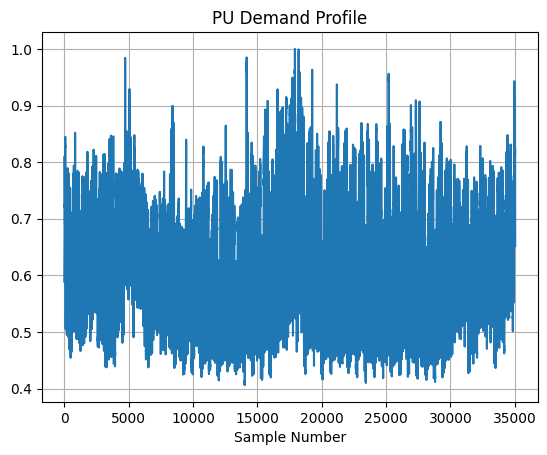

In [5]:
demand_fp = model_dir / 'pu_substation_demand.csv'
demand = pd.read_csv(demand_fp, header=None)
ax = demand.plot(legend=False)  # to show PU demand profile
ax.grid()
ax.set_axisbelow(True)
ax.set_title('PU Demand Profile')
ax.set_xlabel('Sample Number')

In [6]:
# adding 1 to account for opendss first time step being 1
min_idx = demand[0].idxmin() + 1
max_idx = demand[0].idxmax() + 1

time_step_sec = 15 * 60  # 15 minute data

min_t = min_idx * time_step_sec
max_t = max_idx * time_step_sec

# Load (Demand) Hosting Capacity
First, a default call of the standard `NodalSnapshot` function is performed to 
get a baseline result.

As shown below, since `bus_name` is a single string, it must be transformed
into a list to meet function input requirements.


In [7]:
voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=[bus_name])

Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.52 seconds)  


The next two solutions utilize the `at_sec` and `mode` parameters to 
define the time to be simulated, and to ensure that the 
specific profile is used.

In this case, all loads were calibrated such that their `duty` followed the
 demand profile of interest

Further, since the input profile is PU, the expectation is that the max
demand result should be very similar to the standard 'no time' solution.

It is also expected that at the minimum demand time, a different 
hosing capacity result will be calculated.

Simulations are run and results combined into a DataFrame for easier presntation.

In [8]:
vchc_max_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[bus_name],
    mode='duty',
    at_sec=max_t,
    )

Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.52 seconds)  


In [9]:
vchc_min_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[bus_name],
    mode='duty',
    at_sec=min_t,
    save_violations=True,  # NOTE: by default, this is False
    )

Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 3.27 seconds)  


As shown below, the demand based voltage constrained hosting capacity is 
very similar between the initial solve and max demand case, but different
in the minimum demand case.

In [10]:
demand_hc = {
    'initial_solve':voltage_hc.result_df['voltage_hc_kw'],
    'max_demand':vchc_max_demand.result_df['voltage_hc_kw'],
    'min_demand':vchc_min_demand.result_df['voltage_hc_kw']
}

pd.DataFrame.from_dict(demand_hc)

,initial_solve,max_demand,min_demand
p1udt16,15305,15309,24547


The `save_violations` parameter will save all violations found on the
feeder from the last 'violation having' power flow solution so one can 
identify the element and condition that caused the hosting capcity limit
to be found.

As this process increases simulation time, the default setting is `False`.

In [11]:
vchc_min_demand.result_df  # standard dataframe results

,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,24547,18,False,True,True,False,2,1.365715


In [12]:
vchc_min_demand.violations[bus_name]['under_voltage']  # identification of violation at bus_name hosting capacity

,Bus_Name,v1,ang1,v2,ang2,v3,ang3,n_nodes,nodes,over_voltage,under_voltage,zero_voltage,distance,kv_base,primary
0,p1ulv548,0.949998,-124.388186,0.950374,55.682635,NaN,NaN,2,12,False,True,False,1.613386,0.120089,False


Since all violations are stored in the violations dictionary, other issues 
can be identified.

In this case, since there were also line overloading, one may ask 
"how many lines were overloaded?"

In [13]:
vchc_min_demand.violations[bus_name]['n_over_capacity']

68

Since there are many over capacity violations, it is expected that the
thermal constrained hosting capacity will be less than the voltage 
constrianed hosting capacity.

In [14]:
tchc_min_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[bus_name],
    constraint='thermal',
    mode='duty',
    at_sec=min_t,
    save_violations=True,
    )

Started thermal constrained hosting capacity
Bus 1/1  (100.00% complete in 3.56 seconds)  


As expected, the thermal hosting capacity is less than the thermal hosting 
capacity at the originally selected bus.

Additional information in the violations dictionary can lead to the exact 
element in violation.

In [15]:
tchc_min_demand.result_df

,thermal_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt16,2831,18,False,False,True,False,1,1.365715


In [16]:
tchc_min_demand.violations[bus_name]['n_over_capacity']

1

In [17]:
tchc_min_demand.violations[bus_name]['over_capacity']

,Name,Imax,%normal,%emergency,kW,kvar,NumCustomers,TotalCustomers,NumPhases,kVBase,kind,short_name,primary
0,Line.PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375,205.025,100.01,34.17,4487.89,-213.343,0,1237,3,7.2,Line,PADSWITCH(R:P1UDT251-P1UDT252)P1U_9375,True


# Generation (PV) Hosting Capacity
Similarly, the time of simulation also impacts the PV hosting capacity.

Below are results from minimum and maximum demand times assuming a
a generation based hosting capacity is executed.

In [18]:
pv_vchc_max_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[bus_name],
    hc_kind='pv',
    mode='duty',
    at_sec=max_t,
    )


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.45 seconds)  


In [19]:
pv_vchc_min_demand = dreams.hc.NodalSnapshot(
    feeder,
    bus_names=[bus_name],
    hc_kind='pv',
    mode='duty',
    at_sec=min_t,
    )


Started voltage constrained hosting capacity
Bus 1/1  (100.00% complete in 2.48 seconds)  


In this case the maximum demand time allows for a larger system to be
added compared to the minimum demand result.

This makes intuitive sense because the generation source has more load
to feed before voltage issues occur.

In [20]:
pv_hc = {
    'max_demand':pv_vchc_max_demand.result_df['voltage_hc_kw'],
    'min_demand':pv_vchc_min_demand.result_df['voltage_hc_kw']
}
pd.DataFrame.from_dict(pv_hc)


,max_demand,min_demand
p1udt16,13414,10083


# Conclusion
This noteboke showed how the DREAMS nodal hosting capacity function can
be used at different simulated times of a model to produce different results.

This involved defining the `mode`, `at_sec` and optionally the 
`save_violations` parameters to the `NodalSnapshot` hosting capacity function.

In typical, well behaved models, during maximum demand, there is less 
available hosting capacity for additional load, and more hosting capacity
for generation.
However, this may not always be the case due to various model characteristics.

The difference between minimum and maximum demand can have large impacts on 
hosting capacity results.

In the example above, demand voltage hosting capacity varied by ~10 MW between the two 
demand situation while and PV hosting capacity reported nearly a 3 MW 
difference.

The ability to identify elements in violation at a hosting capacity step
can inform planners and researchers of potential system bottle necks or 
other operational issues to address.